In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 
import re


def generate_submission_file(folder_path, models_dict, feature_sets, output_file='risultati/submission.csv'):
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    def extract_number(filepath):
        filename = os.path.basename(filepath)
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else 0

    all_files_sorted = sorted(all_files, key=extract_number)

    results = []
    print(f"\n--- GENERAZIONE SUBMISSION FILE ({len(all_files_sorted)} files) ---")
    
    for file_path in all_files_sorted:
        filename = os.path.basename(file_path)
        file_id = filename.replace('.csv', '') 
        
        try: df_test_raw = pd.read_csv(file_path)
        except: continue
        if df_test_raw.empty: continue
        
        df_test_raw = harmonize_columns(df_test_raw)
        df_mech = prepare_mechanical_data(df_test_raw, is_test=True) 
        df_wash = prepare_wash_data(df_test_raw, is_test=True)       
        
        data_map = {'HPT': df_mech, 'HPC': df_mech, 'WW': df_wash}
        row_pred = {'file': file_id} 
        
        for ctype in ['HPT', 'HPC', 'WW']:
            model = models_dict[ctype]['model']
            margin = models_dict[ctype]['margin']
            imputer = models_dict[ctype]['imputer']
            df = data_map[ctype]
            features = feature_sets[ctype]
            
            if df.empty:
                row_pred[ctype] = 0
                continue
            
            for f in features: 
                if f not in df.columns: df[f] = 0
            
            X_test = df[features]
            X_test = X_test.replace([np.inf, -np.inf], np.nan)
            
            try:
                X_clean = pd.DataFrame(imputer.transform(X_test), columns=features)
                X_clean = X_clean.fillna(0) 
                
                pred_raw = model.predict(X_clean)
                pred_safe = np.maximum(pred_raw - margin, 0)
                final_val = pred_safe[-1] if len(pred_safe) > 0 else 0
                row_pred[ctype] = final_val
            except Exception as e: 
                print(f"Errore su {filename} ({ctype}): {e}")
                row_pred[ctype] = 0
                
        results.append(row_pred)
        
    df_submission = pd.DataFrame(results)
    df_submission = df_submission.rename(columns={
        'WW': 'Cycles_to_WW',
        'HPC': 'Cycles_to_HPC_SV',
        'HPT': 'Cycles_to_HPT_SV'
    })
    
    for col in ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']:
        df_submission[col] = df_submission[col].round(0).astype(int)
        
    df_submission = df_submission[['file', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']]
    
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    df_submission.to_csv(output_file, index=False)
    print(f"File salvato: {output_file}")


# ==============================================================================
# 0. MOTORE FISICO
# ==============================================================================
def harmonize_columns(df):
    rename_map = {
        'Cycles': 'Cycles_Since_New', 'Cycle': 'Cycles_Since_New',
        'Altitude': 'Sensed_Altitude', 'Mach': 'Sensed_Mach',
        'TRA': 'Sensed_TRA', 'T2': 'Sensed_T2', 'T24': 'Sensed_T24',
        'T30': 'Sensed_T3', 'T48': 'Sensed_T45', 'T50': 'Sensed_T5',
        'P15': 'Sensed_P15', 'P2': 'Sensed_P2', 'P21': 'Sensed_P21',
        'P24': 'Sensed_P24', 'Ps30': 'Sensed_Ps3', 'P40': 'Sensed_P40',
        'P50': 'Sensed_P50', 'HPC_SV': 'Cycles_to_HPC_SV',
        'HPT_SV': 'Cycles_to_HPT_SV', 'WW': 'Cycles_to_WW'
    }
    df = df.rename(columns=rename_map)
    if 'Sensed_Altitude' not in df.columns and 'Altitude' not in df.columns:
         for col in df.columns:
             if col not in ['ESN', 'Cycles_Since_New', 'Snapshot', 'File_ID']:
                 if not col.startswith('Sensed_') and not col.startswith('Phy_'):
                     df.rename(columns={col: f'Sensed_{col}'}, inplace=True)
    return df

def add_physics_features(df):
    df = df.copy()
    STD_TEMP_R = 518.67; STD_PRES = 14.696; GAMMA_AIR = 1.4

    if 'Sensed_T25' in df.columns and 'Sensed_Pt2' in df.columns:
        theta = df['Sensed_T25'] / STD_TEMP_R 
        delta = df['Sensed_Pt2'] / STD_PRES
        theta = theta.replace(0, 1); delta = delta.replace(0, 1)

        if 'Sensed_Core_Speed' in df.columns:
            df['Phy_Core_Speed_Corr'] = df['Sensed_Core_Speed'] / np.sqrt(theta)
        if 'Sensed_WFuel' in df.columns:
            df['Phy_WFuel_Corr'] = df['Sensed_WFuel'] / (delta * np.sqrt(theta))
        if 'Sensed_T45' in df.columns:
            df['Phy_T45_Corr'] = df['Sensed_T45'] / theta

        if 'Sensed_T3' in df.columns and 'Sensed_Ps3' in df.columns:
            T_in_R = df['Sensed_T25'] 
            T_out_R = df['Sensed_T3'] 
            P_in = df['Sensed_P25'] if 'Sensed_P25' in df.columns else df['Sensed_Pt2']
            P_out = df['Sensed_Ps3']
            
            pr = P_out / P_in
            k = (GAMMA_AIR - 1) / GAMMA_AIR
            T_iso_R = T_in_R * (pr ** k)
            df['Phy_Compressor_Eff'] = (T_iso_R - T_in_R) / (T_out_R - T_in_R)

    if 'Sensed_T45' in df.columns and 'Sensed_Ps3' in df.columns:
        df['Phy_Heat_Index'] = df['Sensed_T45'] / df['Sensed_Ps3']

    return df

# ==============================================================================
# 1. PREPROCESSING (SOLO FISICA PURA, NO RESIDUI)
# ==============================================================================
def prepare_mechanical_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    df = add_physics_features(df)

    phy_cols = ['Phy_T45_Corr', 'Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_Core_Speed_Corr']
    raw_cols = ['Sensed_Ps3', 'Sensed_T3'] 
    
    # MODIFICA: Utilizziamo solo feature fisiche pulite per evitare mismatch col Test Set
    use_cols = [c for c in phy_cols + raw_cols if c in df.columns]
    
    agg_dict = {col: 'mean' for col in use_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=10, min_periods=1).mean()

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    return df_grouped

def prepare_wash_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    df = add_physics_features(df)
    
    phy_cols = ['Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_WFuel_Corr']
    raw_backup = ['Sensed_WFuel', 'Sensed_T45'] 
    
    # MODIFICA: Utilizziamo solo feature fisiche pulite
    use_cols = [c for c in phy_cols + raw_backup if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = 'max' 
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict)
        
    new_cols = []
    feature_cols = []
    for c, s in df_grouped.columns:
        if c in ['Cycles_to_WW', 'Cumulative_WWs'] or s == '': new_cols.append(c)
        else: 
            name = f"{c}_{s}"
            new_cols.append(name)
            feature_cols.append(name)
    
    df_grouped.columns = new_cols
    df_grouped = df_grouped.reset_index()
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped.groupby('ESN')['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped.groupby('ESN')['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby(['ESN', 'Wash_Session_ID']).cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')

        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).mean()
            )
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()
    else:
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby('Wash_Session_ID').cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')
             
        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=5, min_periods=1).mean()
            df_grouped[f"{col}_diff"] = df_grouped[col].diff()

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    drop_cols = ['WW_Change', 'Wash_Session_ID', 'Cumulative_WWs']
    df_grouped = df_grouped.drop(columns=[c for c in drop_cols if c in df_grouped.columns])
    
    return df_grouped

# ==============================================================================
# 2. METRICHE & UTILS
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# ==============================================================================
# 3. MAIN
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING (FISICA PURA, NO RESIDUI) ---")
    try:
        # Carica il file train_cleaned (quello grezzo prima dei residui) 
        # oppure train_with_physics_residuals, la pipeline ignorerà le colonne dei residui.
        if os.path.exists('data_elaborated/train/train_cleaned.csv'):
            df_raw = pd.read_csv('data_elaborated/train/train_cleaned.csv')
        else:
            df_raw = pd.read_csv('data_elaborated/train/train_with_physics_residuals.csv')
    except:
        print("File non trovato."); return
    
    df_raw = harmonize_columns(df_raw)

    print("\n--- DATASET PREPARATION ---")
    df_mech = prepare_mechanical_data(df_raw, is_test=False)
    df_wash = prepare_wash_data(df_raw, is_test=False)
    
    # MODIFICA: Alpha abbassato (0.01/0.05) per pessimismo matematico intelligente
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT', 'alpha': 0.05, 'margin': 200}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC', 'alpha': 0.05, 'margin': 200},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW',  'alpha': 0.05, 'margin': 15}  
    ]

    trained_models = {}     
    feature_sets = {}

    print("\n============================================================")
    print(" AVVIO TRAINING FINALE E VERIFICA PERFORMANCE")
    print("============================================================")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        alpha_q = task['alpha']
        margin = task['margin']
        
        if target not in df.columns: continue
        
        features = [c for c in df.columns if c not in ['ESN', target, 'Snapshot'] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features 
        
        X = df[features]
        y = df[target]
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        if ctype == 'WW':
            params = {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'alpha': alpha_q, 'subsample': 1.0}
        else:
            params = {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'alpha': alpha_q, 'subsample': 0.7}
            
        print(f">>> Modello {ctype} (Feats: {len(features)})")
        model = GradientBoostingRegressor(
            loss='quantile', alpha=params['alpha'], 
            n_estimators=params['n_estimators'], 
            learning_rate=params['learning_rate'], 
            max_depth=params['max_depth'], 
            subsample=params['subsample'],
            random_state=42
        )
        model.fit(X_clean, y)
        
        y_pred_raw = model.predict(X_clean)
        y_pred_safe = np.maximum(y_pred_raw - margin, 0)
        
        rmse_val = get_rmse(y, y_pred_safe)
        score_val = get_score(y, y_pred_safe, ctype)
        
        print(f"    [TRAIN RESULT] RMSE: {rmse_val:.2f} | Score: {score_val:.4f}\n")
        
        trained_models[ctype] = {'model': model, 'margin': margin, 'target_name': target, 'imputer': imputer}

    TEST_FOLDER_PATH = 'data/val/'  
    if os.path.exists(TEST_FOLDER_PATH):
        generate_submission_file(TEST_FOLDER_PATH, trained_models, feature_sets, output_file='risultati/submission_val_fisica_pura.csv')

    REAL_TEST_PATH = 'data/test/' 
    if os.path.exists(REAL_TEST_PATH):
        print(f"\n--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---")
        generate_submission_file(REAL_TEST_PATH, trained_models, feature_sets, output_file='risultati/submission_final_test_fisica_pura.csv')

if __name__ == "__main__":
    main()

--- CARICAMENTO TRAINING (FISICA PURA, NO RESIDUI) ---

--- DATASET PREPARATION ---

 AVVIO TRAINING FINALE E VERIFICA PERFORMANCE
>>> Modello HPT (Feats: 13)
    [TRAIN RESULT] RMSE: 881.02 | Score: 15.1165

>>> Modello HPC (Feats: 13)
    [TRAIN RESULT] RMSE: 2521.41 | Score: 25.5993

>>> Modello WW (Feats: 62)
    [TRAIN RESULT] RMSE: 128.32 | Score: 2.4729


--- GENERAZIONE SUBMISSION FILE (48 files) ---
File salvato: risultati/submission_val_fisica_pura.csv

--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---

--- GENERAZIONE SUBMISSION FILE (52 files) ---


/Users/niccolo/Desktop/progetto phm america/A - PHM America 2025/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/niccolo/Desktop/progetto phm america/A - PHM America 2025/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/niccolo/Desktop/progetto phm america/A - PHM America 2025/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


File salvato: risultati/submission_final_test_fisica_pura.csv


### SCORE -> 219

### NUOVA PROVA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 
import re

def generate_submission_file(folder_path, models_dict, feature_sets, output_file='risultati/submission.csv'):
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    def extract_number(filepath):
        filename = os.path.basename(filepath)
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else 0

    all_files_sorted = sorted(all_files, key=extract_number)

    results = []
    print(f"\n--- GENERAZIONE SUBMISSION FILE ({len(all_files_sorted)} files) ---")
    
    for file_path in all_files_sorted:
        filename = os.path.basename(file_path)
        file_id = filename.replace('.csv', '') 
        
        try: df_test_raw = pd.read_csv(file_path)
        except: continue
        if df_test_raw.empty: continue
        
        df_test_raw = harmonize_columns(df_test_raw)
        df_mech = prepare_mechanical_data(df_test_raw, is_test=True) 
        df_wash = prepare_wash_data(df_test_raw, is_test=True)       
        
        data_map = {'HPT': df_mech, 'HPC': df_mech, 'WW': df_wash}
        row_pred = {'file': file_id} 
        
        for ctype in ['HPT', 'HPC', 'WW']:
            model = models_dict[ctype]['model']
            margin = models_dict[ctype]['margin']
            imputer = models_dict[ctype]['imputer']
            df = data_map[ctype]
            features = feature_sets[ctype]
            
            if df.empty:
                row_pred[ctype] = 0
                continue
            
            for f in features: 
                if f not in df.columns: df[f] = 0
            
            X_test = df[features]
            X_test = X_test.replace([np.inf, -np.inf], np.nan)
            
            try:
                X_clean = pd.DataFrame(imputer.transform(X_test), columns=features)
                X_clean = X_clean.fillna(0) 
                
                pred_raw = model.predict(X_clean)
                pred_safe = np.maximum(pred_raw - margin, 0)
                final_val = pred_safe[-1] if len(pred_safe) > 0 else 0
                row_pred[ctype] = final_val
            except Exception as e: 
                print(f"Errore su {filename} ({ctype}): {e}")
                row_pred[ctype] = 0
                
        results.append(row_pred)
        
    df_submission = pd.DataFrame(results)
    df_submission = df_submission.rename(columns={
        'WW': 'Cycles_to_WW',
        'HPC': 'Cycles_to_HPC_SV',
        'HPT': 'Cycles_to_HPT_SV'
    })
    
    for col in ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']:
        df_submission[col] = df_submission[col].round(0).astype(int)
        
    df_submission = df_submission[['file', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']]
    
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    df_submission.to_csv(output_file, index=False)
    print(f"File salvato: {output_file}")


# ==============================================================================
# 0. MOTORE FISICO CORRETTO (BUG FIX)
# ==============================================================================
def harmonize_columns(df):
    """ Mappatura esplicita estesa per coprire tutti i file di test """
    rename_map = {
        'Cycles': 'Cycles_Since_New', 'Cycle': 'Cycles_Since_New',
        'Altitude': 'Sensed_Altitude', 'Mach': 'Sensed_Mach',
        'TRA': 'Sensed_TRA', 'T2': 'Sensed_T2', 'T24': 'Sensed_T24',
        'T25': 'Sensed_T25', 'Pt2': 'Sensed_Pt2', 
        'W': 'Sensed_WFuel', 'WFuel': 'Sensed_WFuel',
        'Core_Speed': 'Sensed_Core_Speed', 'N2': 'Sensed_Core_Speed',
        'Fan_Speed': 'Sensed_Fan_Speed', 'N1': 'Sensed_Fan_Speed',
        'T30': 'Sensed_T3', 'T3': 'Sensed_T3', 
        'T48': 'Sensed_T45', 'T45': 'Sensed_T45', 'T50': 'Sensed_T5',
        'P15': 'Sensed_P15', 'P2': 'Sensed_P2', 'P21': 'Sensed_P21',
        'P24': 'Sensed_P24', 'P25': 'Sensed_P25', 
        'Ps30': 'Sensed_Ps3', 'Ps3': 'Sensed_Ps3', 'P40': 'Sensed_P40',
        'P50': 'Sensed_P50', 'HPC_SV': 'Cycles_to_HPC_SV',
        'HPT_SV': 'Cycles_to_HPT_SV', 'WW': 'Cycles_to_WW'
    }
    df = df.rename(columns=rename_map)
    
    # Fallback infallibile: se qualcosa è sfuggito, aggiunge 'Sensed_'
    new_cols = {}
    for col in df.columns:
        if col not in ['ESN', 'Cycles_Since_New', 'Snapshot', 'File_ID', 'file']:
            if not col.startswith('Sensed_') and not col.startswith('Phy_') and not col.startswith('Cycles_to_'):
                new_cols[col] = f'Sensed_{col}'
    
    if new_cols:
        df = df.rename(columns=new_cols)
        
    return df

def add_physics_features(df):
    df = df.copy()
    STD_TEMP_R = 518.67; STD_PRES = 14.696; GAMMA_AIR = 1.4

    if 'Sensed_T25' in df.columns and 'Sensed_Pt2' in df.columns:
        theta = df['Sensed_T25'] / STD_TEMP_R 
        delta = df['Sensed_Pt2'] / STD_PRES
        theta = theta.replace(0, 1); delta = delta.replace(0, 1)

        if 'Sensed_Core_Speed' in df.columns:
            df['Phy_Core_Speed_Corr'] = df['Sensed_Core_Speed'] / np.sqrt(theta)
        if 'Sensed_WFuel' in df.columns:
            df['Phy_WFuel_Corr'] = df['Sensed_WFuel'] / (delta * np.sqrt(theta))
        if 'Sensed_T45' in df.columns:
            df['Phy_T45_Corr'] = df['Sensed_T45'] / theta

        if 'Sensed_T3' in df.columns and 'Sensed_Ps3' in df.columns:
            T_in_R = df['Sensed_T25'] 
            T_out_R = df['Sensed_T3'] 
            P_in = df['Sensed_P25'] if 'Sensed_P25' in df.columns else df['Sensed_Pt2']
            P_out = df['Sensed_Ps3']
            
            pr = P_out / P_in
            k = (GAMMA_AIR - 1) / GAMMA_AIR
            T_iso_R = T_in_R * (pr ** k)
            df['Phy_Compressor_Eff'] = (T_iso_R - T_in_R) / (T_out_R - T_in_R)

    if 'Sensed_T45' in df.columns and 'Sensed_Ps3' in df.columns:
        df['Phy_Heat_Index'] = df['Sensed_T45'] / df['Sensed_Ps3']

    return df

# ==============================================================================
# 1. PREPROCESSING
# ==============================================================================
def prepare_mechanical_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    df = add_physics_features(df)

    phy_cols = ['Phy_T45_Corr', 'Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_Core_Speed_Corr']
    raw_cols = ['Sensed_Ps3', 'Sensed_T3'] 
    
    use_cols = [c for c in phy_cols + raw_cols if c in df.columns]
    
    agg_dict = {col: 'mean' for col in use_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=10, min_periods=1).mean()

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    return df_grouped

def prepare_wash_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    df = add_physics_features(df)
    
    phy_cols = ['Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_WFuel_Corr']
    raw_backup = ['Sensed_WFuel', 'Sensed_T45'] 
    
    use_cols = [c for c in phy_cols + raw_backup if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = 'max' 
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict)
        
    new_cols = []
    feature_cols = []
    for c, s in df_grouped.columns:
        if c in ['Cycles_to_WW', 'Cumulative_WWs'] or s == '': new_cols.append(c)
        else: 
            name = f"{c}_{s}"
            new_cols.append(name)
            feature_cols.append(name)
    
    df_grouped.columns = new_cols
    df_grouped = df_grouped.reset_index()
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped.groupby('ESN')['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped.groupby('ESN')['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby(['ESN', 'Wash_Session_ID']).cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')

        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).mean()
            )
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()
    else:
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby('Wash_Session_ID').cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')
             
        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=5, min_periods=1).mean()
            df_grouped[f"{col}_diff"] = df_grouped[col].diff()

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    drop_cols = ['WW_Change', 'Wash_Session_ID', 'Cumulative_WWs']
    df_grouped = df_grouped.drop(columns=[c for c in drop_cols if c in df_grouped.columns])
    
    return df_grouped

# ==============================================================================
# 2. METRICHE & UTILS
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# ==============================================================================
# 3. MAIN
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING (FISICA PURA, BUG FIX) ---")
    try:
        if os.path.exists('data_elaborated/train/train_cleaned.csv'):
            df_raw = pd.read_csv('data_elaborated/train/train_cleaned.csv')
        else:
            df_raw = pd.read_csv('data_elaborated/train/train_with_physics_residuals.csv')
    except:
        print("File non trovato."); return
    
    df_raw = harmonize_columns(df_raw)

    print("\n--- DATASET PREPARATION ---")
    df_mech = prepare_mechanical_data(df_raw, is_test=False)
    df_wash = prepare_wash_data(df_raw, is_test=False)
    
    # PARAMETRI BILANCIATI: Il modello ora vedrà la termodinamica reale del test set,
    # quindi si abbasserà da solo se il motore sta male.
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT', 'alpha': 0.05, 'margin': 100}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC', 'alpha': 0.05, 'margin': 100},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW',  'alpha': 0.15, 'margin': 10}  
    ]

    trained_models = {}     
    feature_sets = {}

    print("\n============================================================")
    print(" AVVIO TRAINING FINALE E VERIFICA PERFORMANCE")
    print("============================================================")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        alpha_q = task['alpha']
        margin = task['margin']
        
        if target not in df.columns: continue
        
        features = [c for c in df.columns if c not in ['ESN', target, 'Snapshot'] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features 
        
        X = df[features]
        y = df[target]
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        if ctype == 'WW':
            params = {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'alpha': alpha_q, 'subsample': 1.0}
        else:
            params = {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'alpha': alpha_q, 'subsample': 0.7}
            
        print(f">>> Modello {ctype} (Feats: {len(features)})")
        model = GradientBoostingRegressor(
            loss='quantile', alpha=params['alpha'], 
            n_estimators=params['n_estimators'], 
            learning_rate=params['learning_rate'], 
            max_depth=params['max_depth'], 
            subsample=params['subsample'],
            random_state=42
        )
        model.fit(X_clean, y)
        
        y_pred_raw = model.predict(X_clean)
        y_pred_safe = np.maximum(y_pred_raw - margin, 0)
        
        rmse_val = get_rmse(y, y_pred_safe)
        score_val = get_score(y, y_pred_safe, ctype)
        
        print(f"    [TRAIN RESULT] RMSE: {rmse_val:.2f} | Score: {score_val:.4f}\n")
        
        trained_models[ctype] = {'model': model, 'margin': margin, 'target_name': target, 'imputer': imputer}

    TEST_FOLDER_PATH = 'data/val/'  
    if os.path.exists(TEST_FOLDER_PATH):
        generate_submission_file(TEST_FOLDER_PATH, trained_models, feature_sets, output_file='risultati/submission_val_fisica_pura.csv')

    REAL_TEST_PATH = 'data/test/' 
    if os.path.exists(REAL_TEST_PATH):
        print(f"\n--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---")
        generate_submission_file(REAL_TEST_PATH, trained_models, feature_sets, output_file='risultati/submission_final_test_fisica_pura.csv')

if __name__ == "__main__":
    main()

--- CARICAMENTO TRAINING (FISICA PURA, BUG FIX) ---

--- DATASET PREPARATION ---

 AVVIO TRAINING FINALE E VERIFICA PERFORMANCE
>>> Modello HPT (Feats: 13)
    [TRAIN RESULT] RMSE: 805.53 | Score: 12.2957

>>> Modello HPC (Feats: 13)
    [TRAIN RESULT] RMSE: 2446.48 | Score: 23.6471

>>> Modello WW (Feats: 61)


KeyboardInterrupt: 

### SCORE -> 190.4

### NUOVO TENTATIVO

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 
import re

def generate_submission_file(folder_path, models_dict, feature_sets, output_file='risultati/submission.csv'):
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    def extract_number(filepath):
        filename = os.path.basename(filepath)
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else 0

    all_files_sorted = sorted(all_files, key=extract_number)

    results = []
    print(f"\n--- GENERAZIONE SUBMISSION FILE ({len(all_files_sorted)} files) ---")
    
    for file_path in all_files_sorted:
        filename = os.path.basename(file_path)
        file_id = filename.replace('.csv', '') 
        
        try: df_test_raw = pd.read_csv(file_path)
        except: continue
        if df_test_raw.empty: continue
        
        df_test_raw = harmonize_columns(df_test_raw)
        df_mech = prepare_mechanical_data(df_test_raw, is_test=True) 
        df_wash = prepare_wash_data(df_test_raw, is_test=True)       
        
        data_map = {'HPT': df_mech, 'HPC': df_mech, 'WW': df_wash}
        row_pred = {'file': file_id} 
        
        for ctype in ['HPT', 'HPC', 'WW']:
            model = models_dict[ctype]['model']
            margin = models_dict[ctype]['margin']
            imputer = models_dict[ctype]['imputer']
            df = data_map[ctype]
            features = feature_sets[ctype]
            
            if df.empty:
                row_pred[ctype] = 0
                continue
            
            for f in features: 
                if f not in df.columns: df[f] = 0
            
            X_test = df[features]
            X_test = X_test.replace([np.inf, -np.inf], np.nan)
            
            try:
                X_clean = pd.DataFrame(imputer.transform(X_test), columns=features)
                X_clean = X_clean.fillna(0) 
                
                pred_raw = model.predict(X_clean)
                pred_safe = np.maximum(pred_raw - margin, 0)
                final_val = pred_safe[-1] if len(pred_safe) > 0 else 0
                row_pred[ctype] = final_val
            except Exception as e: 
                print(f"Errore su {filename} ({ctype}): {e}")
                row_pred[ctype] = 0
                
        results.append(row_pred)
        
    df_submission = pd.DataFrame(results)
    df_submission = df_submission.rename(columns={
        'WW': 'Cycles_to_WW',
        'HPC': 'Cycles_to_HPC_SV',
        'HPT': 'Cycles_to_HPT_SV'
    })
    
    for col in ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']:
        df_submission[col] = df_submission[col].round(0).astype(int)
        
    df_submission = df_submission[['file', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']]
    
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    df_submission.to_csv(output_file, index=False)
    print(f"File salvato: {output_file}")


# ==============================================================================
# 0. MOTORE FISICO CORRETTO (BUG FIX)
# ==============================================================================
def harmonize_columns(df):
    rename_map = {
        'Cycles': 'Cycles_Since_New', 'Cycle': 'Cycles_Since_New',
        'Altitude': 'Sensed_Altitude', 'Mach': 'Sensed_Mach',
        'TRA': 'Sensed_TRA', 'T2': 'Sensed_T2', 'T24': 'Sensed_T24',
        'T25': 'Sensed_T25', 'Pt2': 'Sensed_Pt2', 
        'W': 'Sensed_WFuel', 'WFuel': 'Sensed_WFuel',
        'Core_Speed': 'Sensed_Core_Speed', 'N2': 'Sensed_Core_Speed',
        'Fan_Speed': 'Sensed_Fan_Speed', 'N1': 'Sensed_Fan_Speed',
        'T30': 'Sensed_T3', 'T3': 'Sensed_T3', 
        'T48': 'Sensed_T45', 'T45': 'Sensed_T45', 'T50': 'Sensed_T5',
        'P15': 'Sensed_P15', 'P2': 'Sensed_P2', 'P21': 'Sensed_P21',
        'P24': 'Sensed_P24', 'P25': 'Sensed_P25', 
        'Ps30': 'Sensed_Ps3', 'Ps3': 'Sensed_Ps3', 'P40': 'Sensed_P40',
        'P50': 'Sensed_P50', 'HPC_SV': 'Cycles_to_HPC_SV',
        'HPT_SV': 'Cycles_to_HPT_SV', 'WW': 'Cycles_to_WW'
    }
    df = df.rename(columns=rename_map)
    
    new_cols = {}
    for col in df.columns:
        if col not in ['ESN', 'Cycles_Since_New', 'Snapshot', 'File_ID', 'file']:
            if not col.startswith('Sensed_') and not col.startswith('Phy_') and not col.startswith('Cycles_to_'):
                new_cols[col] = f'Sensed_{col}'
    
    if new_cols:
        df = df.rename(columns=new_cols)
        
    return df

def add_physics_features(df):
    df = df.copy()
    STD_TEMP_R = 518.67; STD_PRES = 14.696; GAMMA_AIR = 1.4

    if 'Sensed_T25' in df.columns and 'Sensed_Pt2' in df.columns:
        theta = df['Sensed_T25'] / STD_TEMP_R 
        delta = df['Sensed_Pt2'] / STD_PRES
        theta = theta.replace(0, 1); delta = delta.replace(0, 1)

        if 'Sensed_Core_Speed' in df.columns:
            df['Phy_Core_Speed_Corr'] = df['Sensed_Core_Speed'] / np.sqrt(theta)
        if 'Sensed_WFuel' in df.columns:
            df['Phy_WFuel_Corr'] = df['Sensed_WFuel'] / (delta * np.sqrt(theta))
        if 'Sensed_T45' in df.columns:
            df['Phy_T45_Corr'] = df['Sensed_T45'] / theta

        if 'Sensed_T3' in df.columns and 'Sensed_Ps3' in df.columns:
            T_in_R = df['Sensed_T25'] 
            T_out_R = df['Sensed_T3'] 
            P_in = df['Sensed_P25'] if 'Sensed_P25' in df.columns else df['Sensed_Pt2']
            P_out = df['Sensed_Ps3']
            
            pr = P_out / P_in
            k = (GAMMA_AIR - 1) / GAMMA_AIR
            T_iso_R = T_in_R * (pr ** k)
            df['Phy_Compressor_Eff'] = (T_iso_R - T_in_R) / (T_out_R - T_in_R)

    if 'Sensed_T45' in df.columns and 'Sensed_Ps3' in df.columns:
        df['Phy_Heat_Index'] = df['Sensed_T45'] / df['Sensed_Ps3']

    return df

# ==============================================================================
# 1. PREPROCESSING
# ==============================================================================
def prepare_mechanical_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    df = add_physics_features(df)

    phy_cols = ['Phy_T45_Corr', 'Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_Core_Speed_Corr']
    raw_cols = ['Sensed_Ps3', 'Sensed_T3'] 
    
    use_cols = [c for c in phy_cols + raw_cols if c in df.columns]
    
    agg_dict = {col: 'mean' for col in use_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
            # MODIFICA 1: Aggiunto il calcolo del "Trend" per far capire la pendenza del guasto
            df_grouped[f"{col}_trend"] = df_grouped.groupby('ESN')[f"{col}_smooth"].diff(periods=5).fillna(0)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=10, min_periods=1).mean()
            # MODIFICA 1b: Trend aggiunto anche in inferenza
            df_grouped[f"{col}_trend"] = df_grouped[f"{col}_smooth"].diff(periods=5).fillna(0)

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    return df_grouped

def prepare_wash_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    df = add_physics_features(df)
    
    phy_cols = ['Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_WFuel_Corr']
    raw_backup = ['Sensed_WFuel', 'Sensed_T45'] 
    
    use_cols = [c for c in phy_cols + raw_backup if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = 'max' 
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict)
        
    new_cols = []
    feature_cols = []
    for c, s in df_grouped.columns:
        if c in ['Cycles_to_WW', 'Cumulative_WWs'] or s == '': new_cols.append(c)
        else: 
            name = f"{c}_{s}"
            new_cols.append(name)
            feature_cols.append(name)
    
    df_grouped.columns = new_cols
    df_grouped = df_grouped.reset_index()
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped.groupby('ESN')['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped.groupby('ESN')['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby(['ESN', 'Wash_Session_ID']).cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')

        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).mean()
            )
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()
    else:
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby('Wash_Session_ID').cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')
             
        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=5, min_periods=1).mean()
            df_grouped[f"{col}_diff"] = df_grouped[col].diff()

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    drop_cols = ['WW_Change', 'Wash_Session_ID', 'Cumulative_WWs']
    df_grouped = df_grouped.drop(columns=[c for c in drop_cols if c in df_grouped.columns])
    
    return df_grouped

# ==============================================================================
# 2. METRICHE & UTILS
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# ==============================================================================
# 3. MAIN
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING (FISICA PURA, BUG FIX + TREND) ---")
    try:
        if os.path.exists('data_elaborated/train/train_cleaned.csv'):
            df_raw = pd.read_csv('data_elaborated/train/train_cleaned.csv')
        else:
            df_raw = pd.read_csv('data_elaborated/train/train_with_physics_residuals.csv')
    except:
        print("File non trovato."); return
    
    df_raw = harmonize_columns(df_raw)

    print("\n--- DATASET PREPARATION ---")
    df_mech = prepare_mechanical_data(df_raw, is_test=False)
    df_wash = prepare_wash_data(df_raw, is_test=False)
    
    # MODIFICA 2: Il "Goldilocks" Alpha (0.10) per HPT e HPC. 0.15 per il WW.
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT', 'alpha': 0.10, 'margin': 100}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC', 'alpha': 0.10, 'margin': 100},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW',  'alpha': 0.15, 'margin': 10}  
    ]

    trained_models = {}     
    feature_sets = {}

    print("\n============================================================")
    print(" AVVIO TRAINING FINALE E VERIFICA PERFORMANCE")
    print("============================================================")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        alpha_q = task['alpha']
        margin = task['margin']
        
        if target not in df.columns: continue
        
        features = [c for c in df.columns if c not in ['ESN', target, 'Snapshot'] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features 
        
        X = df[features]
        y = df[target]
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        # MODIFICA 3: Modello più profondo e lento (Hyperparameter Tuning) per catturare il trend
        if ctype == 'WW':
            params = {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'alpha': alpha_q, 'subsample': 1.0}
        else:
            params = {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'alpha': alpha_q, 'subsample': 0.7}
            
        print(f">>> Modello {ctype} (Feats: {len(features)})")
        model = GradientBoostingRegressor(
            loss='quantile', alpha=params['alpha'], 
            n_estimators=params['n_estimators'], 
            learning_rate=params['learning_rate'], 
            max_depth=params['max_depth'], 
            subsample=params['subsample'],
            random_state=42
        )
        model.fit(X_clean, y)
        
        y_pred_raw = model.predict(X_clean)
        y_pred_safe = np.maximum(y_pred_raw - margin, 0)
        
        rmse_val = get_rmse(y, y_pred_safe)
        score_val = get_score(y, y_pred_safe, ctype)
        
        print(f"    [TRAIN RESULT] RMSE: {rmse_val:.2f} | Score: {score_val:.4f}\n")
        
        trained_models[ctype] = {'model': model, 'margin': margin, 'target_name': target, 'imputer': imputer}

    TEST_FOLDER_PATH = 'data/val/'  
    if os.path.exists(TEST_FOLDER_PATH):
        generate_submission_file(TEST_FOLDER_PATH, trained_models, feature_sets, output_file='risultati/submission_val_fisica_pura.csv')

    REAL_TEST_PATH = 'data/test/' 
    if os.path.exists(REAL_TEST_PATH):
        print(f"\n--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---")
        generate_submission_file(REAL_TEST_PATH, trained_models, feature_sets, output_file='risultati/submission_final_test_fisica_pura.csv')

if __name__ == "__main__":
    main()

--- CARICAMENTO TRAINING (FISICA PURA, BUG FIX + TREND) ---

--- DATASET PREPARATION ---

 AVVIO TRAINING FINALE E VERIFICA PERFORMANCE
>>> Modello HPT (Feats: 19)
    [TRAIN RESULT] RMSE: 621.60 | Score: 7.1548

>>> Modello HPC (Feats: 19)
    [TRAIN RESULT] RMSE: 1593.38 | Score: 9.8216

>>> Modello WW (Feats: 61)
    [TRAIN RESULT] RMSE: 418.88 | Score: 18.5212


--- GENERAZIONE SUBMISSION FILE (48 files) ---
File salvato: risultati/submission_val_fisica_pura.csv

--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---

--- GENERAZIONE SUBMISSION FILE (52 files) ---


/Users/niccolo/Desktop/progetto phm america/A - PHM America 2025/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/niccolo/Desktop/progetto phm america/A - PHM America 2025/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/niccolo/Desktop/progetto phm america/A - PHM America 2025/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


File salvato: risultati/submission_final_test_fisica_pura.csv


### SCORE -> 167.9

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 
import re

def generate_submission_file(folder_path, models_dict, feature_sets, output_file='risultati/submission.csv'):
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    def extract_number(filepath):
        filename = os.path.basename(filepath)
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else 0

    all_files_sorted = sorted(all_files, key=extract_number)

    results = []
    print(f"\n--- GENERAZIONE SUBMISSION FILE ({len(all_files_sorted)} files) ---")
    
    for file_path in all_files_sorted:
        filename = os.path.basename(file_path)
        file_id = filename.replace('.csv', '') 
        
        try: df_test_raw = pd.read_csv(file_path)
        except: continue
        if df_test_raw.empty: continue
        
        df_test_raw = harmonize_columns(df_test_raw)
        df_mech = prepare_mechanical_data(df_test_raw, is_test=True) 
        df_wash = prepare_wash_data(df_test_raw, is_test=True)       
        
        data_map = {'HPT': df_mech, 'HPC': df_mech, 'WW': df_wash}
        row_pred = {'file': file_id} 
        
        for ctype in ['HPT', 'HPC', 'WW']:
            model = models_dict[ctype]['model']
            margin = models_dict[ctype]['margin']
            imputer = models_dict[ctype]['imputer']
            df = data_map[ctype]
            features = feature_sets[ctype]
            
            if df.empty:
                row_pred[ctype] = 0
                continue
            
            for f in features: 
                if f not in df.columns: df[f] = 0
            
            X_test = df[features]
            X_test = X_test.replace([np.inf, -np.inf], np.nan)
            
            try:
                X_clean = pd.DataFrame(imputer.transform(X_test), columns=features)
                X_clean = X_clean.fillna(0) 
                
                pred_raw = model.predict(X_clean)
                
                # MODIFICA 1: Margine Adattivo (5% di tolleranza proporzionale + margine fisso)
                if ctype == 'WW':
                    pred_safe = pred_raw - margin
                else:
                    pred_safe = (pred_raw * 0.95) - margin
                    
                pred_safe = np.maximum(pred_safe, 0)
                final_val = pred_safe[-1] if len(pred_safe) > 0 else 0
                row_pred[ctype] = final_val
            except Exception as e: 
                print(f"Errore su {filename} ({ctype}): {e}")
                row_pred[ctype] = 0
                
        results.append(row_pred)
        
    df_submission = pd.DataFrame(results)
    df_submission = df_submission.rename(columns={
        'WW': 'Cycles_to_WW',
        'HPC': 'Cycles_to_HPC_SV',
        'HPT': 'Cycles_to_HPT_SV'
    })
    
    for col in ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']:
        df_submission[col] = df_submission[col].round(0).astype(int)
        
    df_submission = df_submission[['file', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']]
    
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    df_submission.to_csv(output_file, index=False)
    print(f"File salvato: {output_file}")


# ==============================================================================
# 0. MOTORE FISICO CORRETTO
# ==============================================================================
def harmonize_columns(df):
    rename_map = {
        'Cycles': 'Cycles_Since_New', 'Cycle': 'Cycles_Since_New',
        'Altitude': 'Sensed_Altitude', 'Mach': 'Sensed_Mach',
        'TRA': 'Sensed_TRA', 'T2': 'Sensed_T2', 'T24': 'Sensed_T24',
        'T25': 'Sensed_T25', 'Pt2': 'Sensed_Pt2', 
        'W': 'Sensed_WFuel', 'WFuel': 'Sensed_WFuel',
        'Core_Speed': 'Sensed_Core_Speed', 'N2': 'Sensed_Core_Speed',
        'Fan_Speed': 'Sensed_Fan_Speed', 'N1': 'Sensed_Fan_Speed',
        'T30': 'Sensed_T3', 'T3': 'Sensed_T3', 
        'T48': 'Sensed_T45', 'T45': 'Sensed_T45', 'T50': 'Sensed_T5',
        'P15': 'Sensed_P15', 'P2': 'Sensed_P2', 'P21': 'Sensed_P21',
        'P24': 'Sensed_P24', 'P25': 'Sensed_P25', 
        'Ps30': 'Sensed_Ps3', 'Ps3': 'Sensed_Ps3', 'P40': 'Sensed_P40',
        'P50': 'Sensed_P50', 'HPC_SV': 'Cycles_to_HPC_SV',
        'HPT_SV': 'Cycles_to_HPT_SV', 'WW': 'Cycles_to_WW'
    }
    df = df.rename(columns=rename_map)
    
    new_cols = {}
    for col in df.columns:
        if col not in ['ESN', 'Cycles_Since_New', 'Snapshot', 'File_ID', 'file']:
            if not col.startswith('Sensed_') and not col.startswith('Phy_') and not col.startswith('Cycles_to_'):
                new_cols[col] = f'Sensed_{col}'
    
    if new_cols:
        df = df.rename(columns=new_cols)
        
    return df

def add_physics_features(df):
    df = df.copy()
    STD_TEMP_R = 518.67; STD_PRES = 14.696; GAMMA_AIR = 1.4

    if 'Sensed_T25' in df.columns and 'Sensed_Pt2' in df.columns:
        theta = df['Sensed_T25'] / STD_TEMP_R 
        delta = df['Sensed_Pt2'] / STD_PRES
        theta = theta.replace(0, 1); delta = delta.replace(0, 1)

        if 'Sensed_Core_Speed' in df.columns:
            df['Phy_Core_Speed_Corr'] = df['Sensed_Core_Speed'] / np.sqrt(theta)
        if 'Sensed_WFuel' in df.columns:
            df['Phy_WFuel_Corr'] = df['Sensed_WFuel'] / (delta * np.sqrt(theta))
        if 'Sensed_T45' in df.columns:
            df['Phy_T45_Corr'] = df['Sensed_T45'] / theta

        if 'Sensed_T3' in df.columns and 'Sensed_Ps3' in df.columns:
            T_in_R = df['Sensed_T25'] 
            T_out_R = df['Sensed_T3'] 
            P_in = df['Sensed_P25'] if 'Sensed_P25' in df.columns else df['Sensed_Pt2']
            P_out = df['Sensed_Ps3']
            
            pr = P_out / P_in
            k = (GAMMA_AIR - 1) / GAMMA_AIR
            T_iso_R = T_in_R * (pr ** k)
            df['Phy_Compressor_Eff'] = (T_iso_R - T_in_R) / (T_out_R - T_in_R)

    if 'Sensed_T45' in df.columns and 'Sensed_Ps3' in df.columns:
        df['Phy_Heat_Index'] = df['Sensed_T45'] / df['Sensed_Ps3']

    return df

# ==============================================================================
# 1. PREPROCESSING
# ==============================================================================
def prepare_mechanical_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    df = add_physics_features(df)

    phy_cols = ['Phy_T45_Corr', 'Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_Core_Speed_Corr']
    raw_cols = ['Sensed_Ps3', 'Sensed_T3'] 
    
    use_cols = [c for c in phy_cols + raw_cols if c in df.columns]
    
    agg_dict = {col: 'mean' for col in use_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
            df_grouped[f"{col}_trend"] = df_grouped.groupby('ESN')[f"{col}_smooth"].diff(periods=5).fillna(0)
            
            # MODIFICA 2: Aggiunta Volatilità del sensore (Std Dev)
            df_grouped[f"{col}_std"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).std()
            ).fillna(0)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=10, min_periods=1).mean()
            df_grouped[f"{col}_trend"] = df_grouped[f"{col}_smooth"].diff(periods=5).fillna(0)
            
            # MODIFICA 2b: Volatilità anche per l'inferenza
            df_grouped[f"{col}_std"] = df_grouped[col].rolling(window=10, min_periods=1).std().fillna(0)

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    return df_grouped

def prepare_wash_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    df = add_physics_features(df)
    
    phy_cols = ['Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_WFuel_Corr']
    raw_backup = ['Sensed_WFuel', 'Sensed_T45'] 
    
    use_cols = [c for c in phy_cols + raw_backup if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = 'max' 
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict)
        
    new_cols = []
    feature_cols = []
    for c, s in df_grouped.columns:
        if c in ['Cycles_to_WW', 'Cumulative_WWs'] or s == '': new_cols.append(c)
        else: 
            name = f"{c}_{s}"
            new_cols.append(name)
            feature_cols.append(name)
    
    df_grouped.columns = new_cols
    df_grouped = df_grouped.reset_index()
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped.groupby('ESN')['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped.groupby('ESN')['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby(['ESN', 'Wash_Session_ID']).cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')

        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).mean()
            )
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()
            
            # Volatilità
            df_grouped[f"{col}_std"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).std()
            ).fillna(0)
    else:
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby('Wash_Session_ID').cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')
             
        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=5, min_periods=1).mean()
            df_grouped[f"{col}_diff"] = df_grouped[col].diff()
            df_grouped[f"{col}_std"] = df_grouped[col].rolling(window=5, min_periods=1).std().fillna(0)

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    drop_cols = ['WW_Change', 'Wash_Session_ID', 'Cumulative_WWs']
    df_grouped = df_grouped.drop(columns=[c for c in drop_cols if c in df_grouped.columns])
    
    return df_grouped

# ==============================================================================
# 2. METRICHE & UTILS
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# ==============================================================================
# 3. MAIN
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING (FISICA PURA, BUG FIX + TREND + VOLATILITÀ) ---")
    try:
        if os.path.exists('data_elaborated/train/train_cleaned.csv'):
            df_raw = pd.read_csv('data_elaborated/train/train_cleaned.csv')
        else:
            df_raw = pd.read_csv('data_elaborated/train/train_with_physics_residuals.csv')
    except:
        print("File non trovato."); return
    
    df_raw = harmonize_columns(df_raw)

    print("\n--- DATASET PREPARATION ---")
    df_mech = prepare_mechanical_data(df_raw, is_test=False)
    df_wash = prepare_wash_data(df_raw, is_test=False)
    
    # MODIFICA 3: Alpha Ottimizzato. Avendo inserito il margine adattivo,
    # possiamo permetterci di alzare l'alpha a 0.15, riducendo le penalità per sottostima.
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT', 'alpha': 0.15, 'margin': 50}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC', 'alpha': 0.15, 'margin': 50},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW',  'alpha': 0.20, 'margin': 10}  
    ]

    trained_models = {}     
    feature_sets = {}

    print("\n============================================================")
    print(" AVVIO TRAINING FINALE E VERIFICA PERFORMANCE")
    print("============================================================")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        alpha_q = task['alpha']
        margin = task['margin']
        
        if target not in df.columns: continue
        
        features = [c for c in df.columns if c not in ['ESN', target, 'Snapshot'] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features 
        
        X = df[features]
        y = df[target]
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        if ctype == 'WW':
            params = {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'alpha': alpha_q, 'subsample': 1.0}
        else:
            params = {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'alpha': alpha_q, 'subsample': 0.7}
            
        print(f">>> Modello {ctype} (Feats: {len(features)})")
        model = GradientBoostingRegressor(
            loss='quantile', alpha=params['alpha'], 
            n_estimators=params['n_estimators'], 
            learning_rate=params['learning_rate'], 
            max_depth=params['max_depth'], 
            subsample=params['subsample'],
            random_state=42
        )
        model.fit(X_clean, y)
        
        y_pred_raw = model.predict(X_clean)
        
        # Margine Adattivo applicato anche al training per calcolare le metriche corrette
        if ctype == 'WW':
            y_pred_safe = y_pred_raw - margin
        else:
            y_pred_safe = (y_pred_raw * 0.95) - margin
            
        y_pred_safe = np.maximum(y_pred_safe, 0)
        
        rmse_val = get_rmse(y, y_pred_safe)
        score_val = get_score(y, y_pred_safe, ctype)
        
        print(f"    [TRAIN RESULT] RMSE: {rmse_val:.2f} | Score: {score_val:.4f}\n")
        
        trained_models[ctype] = {'model': model, 'margin': margin, 'target_name': target, 'imputer': imputer}

    TEST_FOLDER_PATH = 'data/val/'  
    if os.path.exists(TEST_FOLDER_PATH):
        generate_submission_file(TEST_FOLDER_PATH, trained_models, feature_sets, output_file='risultati/submission_val_fisica_pura.csv')

    REAL_TEST_PATH = 'data/test/' 
    if os.path.exists(REAL_TEST_PATH):
        print(f"\n--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---")
        generate_submission_file(REAL_TEST_PATH, trained_models, feature_sets, output_file='risultati/submission_final_test_fisica_pura.csv')

if __name__ == "__main__":
    main()

--- CARICAMENTO TRAINING (FISICA PURA, BUG FIX + TREND + VOLATILITÀ) ---

--- DATASET PREPARATION ---

 AVVIO TRAINING FINALE E VERIFICA PERFORMANCE
>>> Modello HPT (Feats: 25)
    [TRAIN RESULT] RMSE: 570.47 | Score: 5.5642

>>> Modello HPC (Feats: 25)
    [TRAIN RESULT] RMSE: 1321.45 | Score: 6.7822

>>> Modello WW (Feats: 71)
    [TRAIN RESULT] RMSE: 368.10 | Score: 14.7564


--- GENERAZIONE SUBMISSION FILE (48 files) ---
File salvato: risultati/submission_val_fisica_pura.csv

--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---

--- GENERAZIONE SUBMISSION FILE (52 files) ---


/Users/niccolo/Desktop/progetto phm america/A - PHM America 2025/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/niccolo/Desktop/progetto phm america/A - PHM America 2025/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/niccolo/Desktop/progetto phm america/A - PHM America 2025/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


File salvato: risultati/submission_final_test_fisica_pura.csv


### SCORE -> 140.0

### PROVIAMO UN NUOVO APPROCCIO TENENDO LO STESSO PREPOCESSING

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 
from scipy.optimize import minimize
import re

# ==============================================================================
# 0. MOTORE FISICO CORRETTO E PREPROCESSING
# ==============================================================================
def harmonize_columns(df):
    rename_map = {
        'Cycles': 'Cycles_Since_New', 'Cycle': 'Cycles_Since_New',
        'Altitude': 'Sensed_Altitude', 'Mach': 'Sensed_Mach',
        'TRA': 'Sensed_TRA', 'T2': 'Sensed_T2', 'T24': 'Sensed_T24',
        'T25': 'Sensed_T25', 'Pt2': 'Sensed_Pt2', 
        'W': 'Sensed_WFuel', 'WFuel': 'Sensed_WFuel',
        'Core_Speed': 'Sensed_Core_Speed', 'N2': 'Sensed_Core_Speed',
        'Fan_Speed': 'Sensed_Fan_Speed', 'N1': 'Sensed_Fan_Speed',
        'T30': 'Sensed_T3', 'T3': 'Sensed_T3', 
        'T48': 'Sensed_T45', 'T45': 'Sensed_T45', 'T50': 'Sensed_T5',
        'P15': 'Sensed_P15', 'P2': 'Sensed_P2', 'P21': 'Sensed_P21',
        'P24': 'Sensed_P24', 'P25': 'Sensed_P25', 
        'Ps30': 'Sensed_Ps3', 'Ps3': 'Sensed_Ps3', 'P40': 'Sensed_P40',
        'P50': 'Sensed_P50', 'HPC_SV': 'Cycles_to_HPC_SV',
        'HPT_SV': 'Cycles_to_HPT_SV', 'WW': 'Cycles_to_WW'
    }
    df = df.rename(columns=rename_map)
    new_cols = {}
    for col in df.columns:
        if col not in ['ESN', 'Cycles_Since_New', 'Snapshot', 'File_ID', 'file']:
            if not col.startswith('Sensed_') and not col.startswith('Phy_') and not col.startswith('Cycles_to_'):
                new_cols[col] = f'Sensed_{col}'
    if new_cols: df = df.rename(columns=new_cols)
    return df

def add_physics_features(df):
    df = df.copy()
    STD_TEMP_R = 518.67; STD_PRES = 14.696; GAMMA_AIR = 1.4

    if 'Sensed_T25' in df.columns and 'Sensed_Pt2' in df.columns:
        theta = df['Sensed_T25'] / STD_TEMP_R 
        theta = np.maximum(theta, 0.0001)
        delta = df['Sensed_Pt2'] / STD_PRES
        theta = theta.replace(0, 1); delta = delta.replace(0, 1)

        if 'Sensed_Core_Speed' in df.columns:
            df['Phy_Core_Speed_Corr'] = df['Sensed_Core_Speed'] / np.sqrt(theta)
        if 'Sensed_WFuel' in df.columns:
            df['Phy_WFuel_Corr'] = df['Sensed_WFuel'] / (delta * np.sqrt(theta))
        if 'Sensed_T45' in df.columns:
            df['Phy_T45_Corr'] = df['Sensed_T45'] / theta

        if 'Sensed_T3' in df.columns and 'Sensed_Ps3' in df.columns:
            T_in_R = df['Sensed_T25'] 
            T_out_R = df['Sensed_T3'] 
            P_in = df['Sensed_P25'] if 'Sensed_P25' in df.columns else df['Sensed_Pt2']
            P_out = df['Sensed_Ps3']
            pr = P_out / P_in
            k = (GAMMA_AIR - 1) / GAMMA_AIR
            T_iso_R = T_in_R * (pr ** k)
            df['Phy_Compressor_Eff'] = (T_iso_R - T_in_R) / (T_out_R - T_in_R)

    if 'Sensed_T45' in df.columns and 'Sensed_Ps3' in df.columns:
        df['Phy_Heat_Index'] = df['Sensed_T45'] / df['Sensed_Ps3']
    return df

def prepare_mechanical_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    if 'Sensed_Altitude' in df.columns: df = df[df['Sensed_Altitude'] > 20000].copy()
    df = add_physics_features(df)

    phy_cols = ['Phy_T45_Corr', 'Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_Core_Speed_Corr']
    raw_cols = ['Sensed_Ps3', 'Sensed_T3'] 
    use_cols = [c for c in phy_cols + raw_cols if c in df.columns]
    
    agg_dict = {col: 'mean' for col in use_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(lambda x: x.rolling(window=10, min_periods=1).mean())
            df_grouped[f"{col}_trend"] = df_grouped.groupby('ESN')[f"{col}_smooth"].diff(periods=5).fillna(0)
            df_grouped[f"{col}_std"] = df_grouped.groupby('ESN')[col].transform(lambda x: x.rolling(window=10, min_periods=1).std()).fillna(0)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=10, min_periods=1).mean()
            df_grouped[f"{col}_trend"] = df_grouped[f"{col}_smooth"].diff(periods=5).fillna(0)
            df_grouped[f"{col}_std"] = df_grouped[col].rolling(window=10, min_periods=1).std().fillna(0)

    return df_grouped.ffill().bfill().fillna(0)

def prepare_wash_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    if 'Sensed_Core_Speed' in df.columns: df = df[df['Sensed_Core_Speed'] > 8000].copy()
    df = add_physics_features(df)
    
    phy_cols = ['Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_WFuel_Corr']
    raw_backup = ['Sensed_WFuel', 'Sensed_T45'] 
    use_cols = [c for c in phy_cols + raw_backup if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = 'max' 
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict)
        
    new_cols = []
    feature_cols = []
    for c, s in df_grouped.columns:
        if c in ['Cycles_to_WW', 'Cumulative_WWs'] or s == '': new_cols.append(c)
        else: 
            name = f"{c}_{s}"
            new_cols.append(name)
            feature_cols.append(name)
    
    df_grouped.columns = new_cols
    df_grouped = df_grouped.reset_index()
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped.groupby('ESN')['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped.groupby('ESN')['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby(['ESN', 'Wash_Session_ID']).cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')

        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()
            df_grouped[f"{col}_std"] = df_grouped.groupby('ESN')[col].transform(lambda x: x.rolling(window=5, min_periods=1).std()).fillna(0)
    else:
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby('Wash_Session_ID').cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')
             
        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): df_grouped[f"{col}_lag{i}"] = df_grouped[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=5, min_periods=1).mean()
            df_grouped[f"{col}_diff"] = df_grouped[col].diff()
            df_grouped[f"{col}_std"] = df_grouped[col].rolling(window=5, min_periods=1).std().fillna(0)

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    drop_cols = ['WW_Change', 'Wash_Session_ID', 'Cumulative_WWs']
    return df_grouped.drop(columns=[c for c in drop_cols if c in df_grouped.columns])

# ==============================================================================
# 2. METRICA ESATTA DELLA COMPETIZIONE E OTTIMIZZAZIONE (CORE MATEMATICO)
# ==============================================================================
def get_exact_competition_score(y_true, y_pred, component_type, max_train_val):
    """Implementa l'esatta funzione pitonica della competizione."""
    error = y_pred - y_true
    alpha = 0.01
    beta = 1.0 / max_train_val if component_type == 'WW' else 2.0 / max_train_val
    w = np.where(error >= 0, 2.0 / (1.0 + alpha * y_true), 1.0 / (1.0 + alpha * y_true))
    return np.mean(w * (error ** 2) * beta)

def optimize_margins_oof(X_df, y_series, groups, model_params, ctype, max_train_val):
    """
    Trova il moltiplicatore (A) e l'offset (B) perfetti simulando il test set 
    tramite Out-Of-Fold Cross Validation per evitare l'overfitting.
    """
    gkf = GroupKFold(n_splits=4)
    oof_preds = np.zeros(len(X_df))
    
    # Per evitare problemi con gli indici Pandas
    X_arr = X_df.values
    y_arr = y_series.values
    groups_arr = groups.values

    # 1. Creiamo le predizioni "Cieche" sul training set
    for train_idx, val_idx in gkf.split(X_arr, y_arr, groups=groups_arr):
        X_tr, y_tr = X_arr[train_idx], y_arr[train_idx]
        X_v = X_arr[val_idx]
        
        model = GradientBoostingRegressor(**model_params)
        model.fit(X_tr, y_tr)
        oof_preds[val_idx] = model.predict(X_v)

    # 2. Ottimizziamo la metrica esatta della gara su queste predizioni cieche
    def objective(params):
        a, b = params
        y_adj = np.maximum(0, oof_preds * a + b)
        return get_exact_competition_score(y_arr, y_adj, ctype, max_train_val)

    # Punto di partenza: i tuoi intuitivi (e ottimi) 0.95 e -50
    res = minimize(objective, x0=[0.95, -50.0], method='Nelder-Mead')
    best_a, best_b = res.x
    
    score_base = get_exact_competition_score(y_arr, np.maximum(0, oof_preds), ctype, max_train_val)
    print(f"    [OOF] Score Pieno (Senza Margini): {score_base:.4f}")
    print(f"    [OOF] Score Ottimizzato (Con Margini): {res.fun:.4f}")
    print(f"    [OOF] Moltiplicatore Trovato: {best_a:.4f} | Offset: {best_b:.2f}")

    # 3. Addestriamo il modello finale su TUTTI i dati per avere la massima precisione
    final_model = GradientBoostingRegressor(**model_params)
    final_model.fit(X_arr, y_arr)

    return final_model, best_a, best_b

# ==============================================================================
# 3. GENERAZIONE SUBMISSION
# ==============================================================================
def generate_submission_file(folder_path, models_dict, feature_sets, output_file='risultati/submission.csv'):
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    def extract_number(filepath):
        match = re.search(r'\d+', os.path.basename(filepath))
        return int(match.group()) if match else 0

    all_files_sorted = sorted(all_files, key=extract_number)
    results = []
    print(f"\n--- GENERAZIONE SUBMISSION FILE ({len(all_files_sorted)} files) ---")
    
    for file_path in all_files_sorted:
        file_id = os.path.basename(file_path).replace('.csv', '') 
        
        try: df_test_raw = pd.read_csv(file_path)
        except: continue
        if df_test_raw.empty: continue
        
        df_test_raw = harmonize_columns(df_test_raw)
        df_mech = prepare_mechanical_data(df_test_raw, is_test=True) 
        df_wash = prepare_wash_data(df_test_raw, is_test=True)       
        
        data_map = {'HPT': df_mech, 'HPC': df_mech, 'WW': df_wash}
        row_pred = {'file': file_id} 
        
        for ctype in ['HPT', 'HPC', 'WW']:
            model = models_dict[ctype]['model']
            best_a = models_dict[ctype]['a']
            best_b = models_dict[ctype]['b']
            imputer = models_dict[ctype]['imputer']
            df = data_map[ctype]
            features = feature_sets[ctype]
            
            if df.empty:
                row_pred[ctype] = 0; continue
            for f in features: 
                if f not in df.columns: df[f] = 0
            
            X_test = df[features].replace([np.inf, -np.inf], np.nan)
            
            try:
                X_clean = pd.DataFrame(imputer.transform(X_test), columns=features).fillna(0) 
                
                # INFERENZA CON I MARGINI OTTIMIZZATI MATEMATICAMENTE
                pred_raw = model.predict(X_clean.values)
                pred_safe = (pred_raw[-1] * best_a) + best_b
                
                row_pred[ctype] = max(0, pred_safe)
            except Exception as e: 
                print(f"Errore su {file_id} ({ctype}): {e}")
                row_pred[ctype] = 0
                
        results.append(row_pred)
        
    df_submission = pd.DataFrame(results).rename(columns={
        'WW': 'Cycles_to_WW', 'HPC': 'Cycles_to_HPC_SV', 'HPT': 'Cycles_to_HPT_SV'
    })
    for col in ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']:
        df_submission[col] = df_submission[col].round(0).astype(int)
        
    df_submission = df_submission[['file', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']]
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    df_submission.to_csv(output_file, index=False)
    print(f"File salvato: {output_file}")


# ==============================================================================
# 4. MAIN E TRAINING LOOP
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING ---")
    try:
        if os.path.exists('data_elaborated/train/train_cleaned.csv'):
            df_raw = pd.read_csv('data_elaborated/train/train_cleaned.csv')
        else:
            df_raw = pd.read_csv('data_elaborated/train/train_with_physics_residuals.csv')
    except:
        print("File non trovato."); return
    
    df_raw = harmonize_columns(df_raw)

    print("\n--- DATASET PREPARATION ---")
    df_mech = prepare_mechanical_data(df_raw, is_test=False)
    df_wash = prepare_wash_data(df_raw, is_test=False)
    
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT'}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC'},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW'}  
    ]

    trained_models = {}     
    feature_sets = {}

    print("\n============================================================")
    print(" AVVIO TRAINING E OOF MARGIN OPTIMIZATION (RISK MINIMIZATION)")
    print("============================================================")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        
        if target not in df.columns or 'ESN' not in df.columns: 
            print(f"Skipping {ctype} - missing target or ESN column.")
            continue
        
        features = [c for c in df.columns if c not in ['ESN', target, 'Snapshot'] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features 
        
        X = df[features]
        y = df[target]
        groups = df['ESN'] # Cruciale per simulare il test set ed evitare il leakage!
        
        max_train_val = y.max()
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        print(f"\n>>> Modello {ctype} (Feats: {len(features)})")
        
        # Usiamo HUBER Loss. È il modello più robusto in assoluto (che non overfitta)
        # Funge da base solida, i margini verranno aggiustati a valle dall'OOF.
        if ctype == 'WW':
            params = {'loss': 'huber', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 1.0, 'random_state': 42}
        else:
            params = {'loss': 'huber', 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.7, 'random_state': 42}
            
        # Il cuore della nuova architettura
        final_model, best_a, best_b = optimize_margins_oof(X_clean, y, groups, params, ctype, max_train_val)
        
        trained_models[ctype] = {
            'model': final_model, 
            'imputer': imputer,
            'a': best_a,
            'b': best_b
        }

    TEST_FOLDER_PATH = 'data/val/'  
    if os.path.exists(TEST_FOLDER_PATH):
        generate_submission_file(TEST_FOLDER_PATH, trained_models, feature_sets, output_file='risultati/submission_val_OOF.csv')

    REAL_TEST_PATH = 'data/test/' 
    if os.path.exists(REAL_TEST_PATH):
        print(f"\n--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---")
        generate_submission_file(REAL_TEST_PATH, trained_models, feature_sets, output_file='risultati/submission_final.csv')

if __name__ == "__main__":
    main()

--- CARICAMENTO TRAINING ---

--- DATASET PREPARATION ---

 AVVIO TRAINING E OOF MARGIN OPTIMIZATION (RISK MINIMIZATION)

>>> Modello HPT (Feats: 25)
    [OOF] Score Pieno (Senza Margini): 92.5392
    [OOF] Score Ottimizzato (Con Margini): 28.8494
    [OOF] Moltiplicatore Trovato: 0.4592 | Offset: -5.49

>>> Modello HPC (Feats: 25)
    [OOF] Score Pieno (Senza Margini): 72.4669
    [OOF] Score Ottimizzato (Con Margini): 42.2990
    [OOF] Moltiplicatore Trovato: 0.4765 | Offset: 214.28

>>> Modello WW (Feats: 71)
    [OOF] Score Pieno (Senza Margini): 50.5098
    [OOF] Score Ottimizzato (Con Margini): 19.7857
    [OOF] Moltiplicatore Trovato: 0.1396 | Offset: 163.65

--- GENERAZIONE SUBMISSION FILE (48 files) ---
File salvato: risultati/submission_val_OOF.csv

--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---

--- GENERAZIONE SUBMISSION FILE (52 files) ---
File salvato: risultati/submission_final.csv


### SCORE -> 78.26
LEZGOSKI

Attualmente, il nostro codice addestra tre modelli completamente separati: uno per HPT, uno per HPC e uno per WW. Ma nella realtà termodinamica di un motore, questi tre eventi sono strettamente collegati.

Creiamo una "Catena di Predizioni"

1.  Addestri il modello per il WW e generi le predizioni.

2.  Usi le predizioni del WW come nuova feature in input per addestrare il modello HPC.

3.  Usi le predizioni del WW e dell'HPC come nuove feature in input per il modello HPT.
In questo modo, il modello della turbina saprà in anticipo quando avverranno i lavaggi e quando si romperà il compressore, migliorando drasticamente la sua precisione.

In [2]:
import pandas as pd
import numpy as np
import os
import glob
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 
from scipy.optimize import minimize
import re

# ==============================================================================
# 0. MOTORE FISICO CORRETTO E PREPROCESSING
# ==============================================================================
def harmonize_columns(df):
    rename_map = {
        'Cycles': 'Cycles_Since_New', 'Cycle': 'Cycles_Since_New',
        'Altitude': 'Sensed_Altitude', 'Mach': 'Sensed_Mach',
        'TRA': 'Sensed_TRA', 'T2': 'Sensed_T2', 'T24': 'Sensed_T24',
        'T25': 'Sensed_T25', 'Pt2': 'Sensed_Pt2', 
        'W': 'Sensed_WFuel', 'WFuel': 'Sensed_WFuel',
        'Core_Speed': 'Sensed_Core_Speed', 'N2': 'Sensed_Core_Speed',
        'Fan_Speed': 'Sensed_Fan_Speed', 'N1': 'Sensed_Fan_Speed',
        'T30': 'Sensed_T3', 'T3': 'Sensed_T3', 
        'T48': 'Sensed_T45', 'T45': 'Sensed_T45', 'T50': 'Sensed_T5',
        'P15': 'Sensed_P15', 'P2': 'Sensed_P2', 'P21': 'Sensed_P21',
        'P24': 'Sensed_P24', 'P25': 'Sensed_P25', 
        'Ps30': 'Sensed_Ps3', 'Ps3': 'Sensed_Ps3', 'P40': 'Sensed_P40',
        'P50': 'Sensed_P50', 'HPC_SV': 'Cycles_to_HPC_SV',
        'HPT_SV': 'Cycles_to_HPT_SV', 'WW': 'Cycles_to_WW'
    }
    df = df.rename(columns=rename_map)
    new_cols = {}
    for col in df.columns:
        if col not in ['ESN', 'Cycles_Since_New', 'Snapshot', 'File_ID', 'file']:
            if not col.startswith('Sensed_') and not col.startswith('Phy_') and not col.startswith('Cycles_to_'):
                new_cols[col] = f'Sensed_{col}'
    if new_cols: df = df.rename(columns=new_cols)
    return df

def add_physics_features(df):
    df = df.copy()
    STD_TEMP_R = 518.67; STD_PRES = 14.696; GAMMA_AIR = 1.4

    if 'Sensed_T25' in df.columns and 'Sensed_Pt2' in df.columns:
        theta = df['Sensed_T25'] / STD_TEMP_R 
        theta = np.maximum(theta, 0.0001)
        delta = df['Sensed_Pt2'] / STD_PRES
        theta = theta.replace(0, 1); delta = delta.replace(0, 1)

        if 'Sensed_Core_Speed' in df.columns:
            df['Phy_Core_Speed_Corr'] = df['Sensed_Core_Speed'] / np.sqrt(theta)
        if 'Sensed_WFuel' in df.columns:
            df['Phy_WFuel_Corr'] = df['Sensed_WFuel'] / (delta * np.sqrt(theta))
        if 'Sensed_T45' in df.columns:
            df['Phy_T45_Corr'] = df['Sensed_T45'] / theta

        if 'Sensed_T3' in df.columns and 'Sensed_Ps3' in df.columns:
            T_in_R = df['Sensed_T25'] 
            T_out_R = df['Sensed_T3'] 
            P_in = df['Sensed_P25'] if 'Sensed_P25' in df.columns else df['Sensed_Pt2']
            P_out = df['Sensed_Ps3']
            pr = P_out / P_in
            k = (GAMMA_AIR - 1) / GAMMA_AIR
            T_iso_R = T_in_R * (pr ** k)
            df['Phy_Compressor_Eff'] = (T_iso_R - T_in_R) / (T_out_R - T_in_R)

    if 'Sensed_T45' in df.columns and 'Sensed_Ps3' in df.columns:
        df['Phy_Heat_Index'] = df['Sensed_T45'] / df['Sensed_Ps3']
    return df

def prepare_mechanical_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    if 'Sensed_Altitude' in df.columns: df = df[df['Sensed_Altitude'] > 20000].copy()
    df = add_physics_features(df)

    phy_cols = ['Phy_T45_Corr', 'Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_Core_Speed_Corr']
    raw_cols = ['Sensed_Ps3', 'Sensed_T3'] 
    use_cols = [c for c in phy_cols + raw_cols if c in df.columns]
    
    agg_dict = {col: 'mean' for col in use_cols}
    
    # MODIFICA IMPORTANTE: Aggreghiamo tutti i target per poterli usare nel Multi-Tasking
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV', 'Cycles_to_WW']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(lambda x: x.rolling(window=10, min_periods=1).mean())
            df_grouped[f"{col}_trend"] = df_grouped.groupby('ESN')[f"{col}_smooth"].diff(periods=5).fillna(0)
            df_grouped[f"{col}_std"] = df_grouped.groupby('ESN')[col].transform(lambda x: x.rolling(window=10, min_periods=1).std()).fillna(0)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=10, min_periods=1).mean()
            df_grouped[f"{col}_trend"] = df_grouped[f"{col}_smooth"].diff(periods=5).fillna(0)
            df_grouped[f"{col}_std"] = df_grouped[col].rolling(window=10, min_periods=1).std().fillna(0)

    return df_grouped.ffill().bfill().fillna(0)

def prepare_wash_data(df, is_test=False):
    df = df.copy()
    df = harmonize_columns(df)
    if 'Sensed_Core_Speed' in df.columns: df = df[df['Sensed_Core_Speed'] > 8000].copy()
    df = add_physics_features(df)
    
    phy_cols = ['Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_WFuel_Corr']
    raw_backup = ['Sensed_WFuel', 'Sensed_T45'] 
    use_cols = [c for c in phy_cols + raw_backup if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = 'max' 
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
    else:
        df_grouped = df.groupby('Cycles_Since_New').agg(agg_dict)
        
    new_cols = []
    feature_cols = []
    for c, s in df_grouped.columns:
        if c in ['Cycles_to_WW', 'Cumulative_WWs'] or s == '': new_cols.append(c)
        else: 
            name = f"{c}_{s}"
            new_cols.append(name)
            feature_cols.append(name)
    
    df_grouped.columns = new_cols
    df_grouped = df_grouped.reset_index()
    
    if not is_test and 'ESN' in df.columns:
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped.groupby('ESN')['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped.groupby('ESN')['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby(['ESN', 'Wash_Session_ID']).cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')

        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()
            df_grouped[f"{col}_std"] = df_grouped.groupby('ESN')[col].transform(lambda x: x.rolling(window=5, min_periods=1).std()).fillna(0)
    else:
        df_grouped = df_grouped.sort_values('Cycles_Since_New')
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby('Wash_Session_ID').cumcount()
             feature_cols.append('Cycles_Since_Last_Wash')
             
        for col in feature_cols:
            if col == 'Cycles_Since_Last_Wash': continue 
            for i in range(1, 4): df_grouped[f"{col}_lag{i}"] = df_grouped[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped[col].rolling(window=5, min_periods=1).mean()
            df_grouped[f"{col}_diff"] = df_grouped[col].diff()
            df_grouped[f"{col}_std"] = df_grouped[col].rolling(window=5, min_periods=1).std().fillna(0)

    df_grouped = df_grouped.ffill().bfill().fillna(0)
    drop_cols = ['WW_Change', 'Wash_Session_ID', 'Cumulative_WWs']
    return df_grouped.drop(columns=[c for c in drop_cols if c in df_grouped.columns])

# ==============================================================================
# 2. METRICA ESATTA DELLA COMPETIZIONE E OTTIMIZZAZIONE
# ==============================================================================
def get_exact_competition_score(y_true, y_pred, component_type, max_train_val):
    error = y_pred - y_true
    alpha = 0.01
    beta = 1.0 / max_train_val if component_type == 'WW' else 2.0 / max_train_val
    w = np.where(error >= 0, 2.0 / (1.0 + alpha * y_true), 1.0 / (1.0 + alpha * y_true))
    return np.mean(w * (error ** 2) * beta)

def optimize_margins_oof(X_df, y_series, groups, model_params, ctype, max_train_val):
    gkf = GroupKFold(n_splits=4)
    oof_preds = np.zeros(len(X_df))
    
    X_arr = X_df.values
    y_arr = y_series.values
    groups_arr = groups.values

    for train_idx, val_idx in gkf.split(X_arr, y_arr, groups=groups_arr):
        X_tr, y_tr = X_arr[train_idx], y_arr[train_idx]
        X_v = X_arr[val_idx]
        
        model = GradientBoostingRegressor(**model_params)
        model.fit(X_tr, y_tr)
        oof_preds[val_idx] = model.predict(X_v)

    def objective(params):
        a, b = params
        y_adj = np.maximum(0, oof_preds * a + b)
        return get_exact_competition_score(y_arr, y_adj, ctype, max_train_val)

    res = minimize(objective, x0=[0.95, -50.0], method='Nelder-Mead')
    best_a, best_b = res.x
    
    score_base = get_exact_competition_score(y_arr, np.maximum(0, oof_preds), ctype, max_train_val)
    print(f"    [OOF] Score Pieno (Senza Margini): {score_base:.4f}")
    print(f"    [OOF] Score Ottimizzato (Con Margini): {res.fun:.4f}")
    print(f"    [OOF] Moltiplicatore Trovato: {best_a:.4f} | Offset: {best_b:.2f}")

    final_model = GradientBoostingRegressor(**model_params)
    final_model.fit(X_arr, y_arr)

    # Restituiamo anche le predizioni PURE per passarle ai modelli successivi!
    return final_model, best_a, best_b, oof_preds

# ==============================================================================
# 3. GENERAZIONE SUBMISSION (EFFETTO DOMINO IN INFERENZA)
# ==============================================================================
def generate_submission_file(folder_path, models_dict, feature_sets, output_file='risultati/submission.csv'):
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    def extract_number(filepath):
        match = re.search(r'\d+', os.path.basename(filepath))
        return int(match.group()) if match else 0

    all_files_sorted = sorted(all_files, key=extract_number)
    results = []
    print(f"\n--- GENERAZIONE SUBMISSION FILE ({len(all_files_sorted)} files) ---")
    
    for file_path in all_files_sorted:
        file_id = os.path.basename(file_path).replace('.csv', '') 
        
        try: df_test_raw = pd.read_csv(file_path)
        except: continue
        if df_test_raw.empty: continue
        
        df_test_raw = harmonize_columns(df_test_raw)
        df_mech = prepare_mechanical_data(df_test_raw, is_test=True) 
        df_wash = prepare_wash_data(df_test_raw, is_test=True)       
        
        data_map = {'HPT': df_mech, 'HPC': df_mech, 'WW': df_wash}
        row_pred = {'file': file_id} 
        pure_preds = {} # Salva le predizioni pure per lo stacking
        
        # ORDINE TASSATIVO PER EFFETTO DOMINO: Prima WW, poi HPC, infine HPT
        for ctype in ['WW', 'HPC', 'HPT']: 
            model = models_dict[ctype]['model']
            best_a = models_dict[ctype]['a']
            best_b = models_dict[ctype]['b']
            imputer = models_dict[ctype]['imputer']
            df = data_map[ctype].copy()
            features = feature_sets[ctype]
            
            if df.empty:
                row_pred[ctype] = 0; pure_preds[ctype] = 0; continue
                
            # INIEZIONE DELLE FEATURE PREDETTE (Stacking)
            if ctype == 'HPC':
                df['Pred_WW'] = pure_preds.get('WW', 0)
            elif ctype == 'HPT':
                df['Pred_WW'] = pure_preds.get('WW', 0)
                df['Pred_HPC'] = pure_preds.get('HPC', 0)
                
            for f in features: 
                if f not in df.columns: df[f] = 0
            
            X_test = df[features].replace([np.inf, -np.inf], np.nan)
            
            try:
                X_clean = pd.DataFrame(imputer.transform(X_test), columns=features).fillna(0) 
                
                # LA PREDIZIONE
                pred_raw = model.predict(X_clean.values)[-1]
                pred_safe = (pred_raw * best_a) + best_b
                
                pure_preds[ctype] = pred_raw # Salviamo la "verità" per il prossimo modello
                row_pred[ctype] = max(0, pred_safe) # Salviamo il "margine" per la submission
            except Exception as e: 
                print(f"Errore su {file_id} ({ctype}): {e}")
                row_pred[ctype] = 0; pure_preds[ctype] = 0
                
        results.append(row_pred)
        
    df_submission = pd.DataFrame(results).rename(columns={
        'WW': 'Cycles_to_WW', 'HPC': 'Cycles_to_HPC_SV', 'HPT': 'Cycles_to_HPT_SV'
    })
    for col in ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']:
        df_submission[col] = df_submission[col].round(0).astype(int)
        
    df_submission = df_submission[['file', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']]
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    df_submission.to_csv(output_file, index=False)
    print(f"File salvato: {output_file}")

# ==============================================================================
# 4. MAIN E TRAINING LOOP (EFFETTO DOMINO IN ADDESTRAMENTO)
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING ---")
    try:
        if os.path.exists('data_elaborated/train/train_cleaned.csv'):
            df_raw = pd.read_csv('data_elaborated/train/train_cleaned.csv')
        else:
            df_raw = pd.read_csv('data_elaborated/train/train_with_physics_residuals.csv')
    except:
        print("File non trovato."); return
    
    df_raw = harmonize_columns(df_raw)

    print("\n--- DATASET PREPARATION ---")
    df_mech = prepare_mechanical_data(df_raw, is_test=False)
    df_wash = prepare_wash_data(df_raw, is_test=False)
    
    # ORDINE TASSATIVO: Bisogna addestrare WW per passare la info a HPC, e poi a HPT
    tasks = [
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW'},
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC'},
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT'}
    ]

    trained_models = {}     
    feature_sets = {}
    oof_predictions_dict = {} # Salverà le predizioni cieche

    print("\n============================================================")
    print(" AVVIO TRAINING MULTI-TASK (EFFETTO DOMINO & OOF OPTIMIZATION)")
    print("============================================================")

    for task in tasks:
        target = task['target']
        df = task['data'].copy()
        ctype = task['type']
        
        if target not in df.columns or 'ESN' not in df.columns: continue
        
        # INIEZIONE DELLE FEATURE OOF (Costruiamo la catena del degrado)
        if ctype == 'HPC':
            df = df.set_index(['ESN', 'Cycles_Since_New'])
            df['Pred_WW'] = oof_predictions_dict['WW']
            df = df.reset_index()
            # Se manca qualche indice per asimmetria dei filtri, usiamo il target reale come paracadute
            df['Pred_WW'] = df['Pred_WW'].fillna(df['Cycles_to_WW']) 
            
        elif ctype == 'HPT':
            df = df.set_index(['ESN', 'Cycles_Since_New'])
            df['Pred_WW'] = oof_predictions_dict['WW']
            df['Pred_HPC'] = oof_predictions_dict['HPC']
            df = df.reset_index()
            df['Pred_WW'] = df['Pred_WW'].fillna(df['Cycles_to_WW'])
            df['Pred_HPC'] = df['Pred_HPC'].fillna(df['Cycles_to_HPC_SV'])

        # Selezioniamo le features (ora includono in automatico Pred_WW e Pred_HPC)
        features = [c for c in df.columns if c not in ['ESN', target, 'Snapshot'] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features 
        
        X = df[features]
        y = df[target]
        groups = df['ESN'] 
        max_train_val = y.max()
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        print(f"\n>>> Modello {ctype} (Feats: {len(features)})")
        
        if ctype == 'WW':
            params = {'loss': 'huber', 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 1.0, 'random_state': 42}
        else:
            params = {'loss': 'huber', 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.7, 'random_state': 42}
            
        final_model, best_a, best_b, oof_preds = optimize_margins_oof(X_clean, y, groups, params, ctype, max_train_val)
        
        # Registriamo l'OOF per i modelli a valle usando ESN e Cicli per un mapping chirurgico
        oof_series = pd.Series(oof_preds, index=pd.MultiIndex.from_arrays([df['ESN'], df['Cycles_Since_New']]))
        oof_predictions_dict[ctype] = oof_series
        
        trained_models[ctype] = {
            'model': final_model, 
            'imputer': imputer,
            'a': best_a,
            'b': best_b
        }

    TEST_FOLDER_PATH = 'data/val/'  
    if os.path.exists(TEST_FOLDER_PATH):
        generate_submission_file(TEST_FOLDER_PATH, trained_models, feature_sets, output_file='risultati/submission_val_Domino.csv')

    REAL_TEST_PATH = 'data/test/' 
    if os.path.exists(REAL_TEST_PATH):
        print(f"\n--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---")
        generate_submission_file(REAL_TEST_PATH, trained_models, feature_sets, output_file='risultati/submission_final.csv')

if __name__ == "__main__":
    main()

--- CARICAMENTO TRAINING ---

--- DATASET PREPARATION ---

 AVVIO TRAINING MULTI-TASK (EFFETTO DOMINO & OOF OPTIMIZATION)

>>> Modello WW (Feats: 71)
    [OOF] Score Pieno (Senza Margini): 50.5098
    [OOF] Score Ottimizzato (Con Margini): 19.7857
    [OOF] Moltiplicatore Trovato: 0.1396 | Offset: 163.65

>>> Modello HPC (Feats: 26)
    [OOF] Score Pieno (Senza Margini): 72.1882
    [OOF] Score Ottimizzato (Con Margini): 42.4760
    [OOF] Moltiplicatore Trovato: 0.4657 | Offset: 256.94

>>> Modello HPT (Feats: 27)
    [OOF] Score Pieno (Senza Margini): 88.6346
    [OOF] Score Ottimizzato (Con Margini): 29.1021
    [OOF] Moltiplicatore Trovato: 0.4670 | Offset: -7.84

--- GENERAZIONE SUBMISSION FILE (48 files) ---
File salvato: risultati/submission_val_Domino.csv

--- AVVIO GENERAZIONE SUBMISSION FINALE (Test Set) ---

--- GENERAZIONE SUBMISSION FILE (52 files) ---
File salvato: risultati/submission_final.csv


### SCORE -> 71.01

    [OOF] Score Pieno (Senza Margini): 50.5098
    [OOF] Score Ottimizzato (Con Margini): 19.7857
    [OOF] Moltiplicatore Trovato: 0.1396 | Offset: 163.65
    [OOF] Score Pieno (Senza Margini): 72.1882
    [OOF] Score Ottimizzato (Con Margini): 42.4760
    [OOF] Moltiplicatore Trovato: 0.4657 | Offset: 256.94
    [OOF] Score Pieno (Senza Margini): 88.6346
    [OOF] Score Ottimizzato (Con Margini): 29.1021
    [OOF] Moltiplicatore Trovato: 0.4670 | Offset: -7.84

[WW] Top 5 feature:
   Cycles_Since_New                    0.4336
   Phy_Compressor_Eff_mean_smooth      0.0632
   Phy_Compressor_Eff_max_smooth       0.0561
   Sensed_T45_mean_smooth              0.0283
   Phy_WFuel_Corr_max_smooth           0.0231

[HPC] Top 5 feature:
   Cycles_Since_New                    0.6197
   Phy_Compressor_Eff_smooth           0.1518
   Phy_T45_Corr_smooth                 0.1082
   Sensed_T3_smooth                    0.0676
   Phy_Compressor_Eff                  0.0204

[HPT] Top 5 feature:
   Phy_C

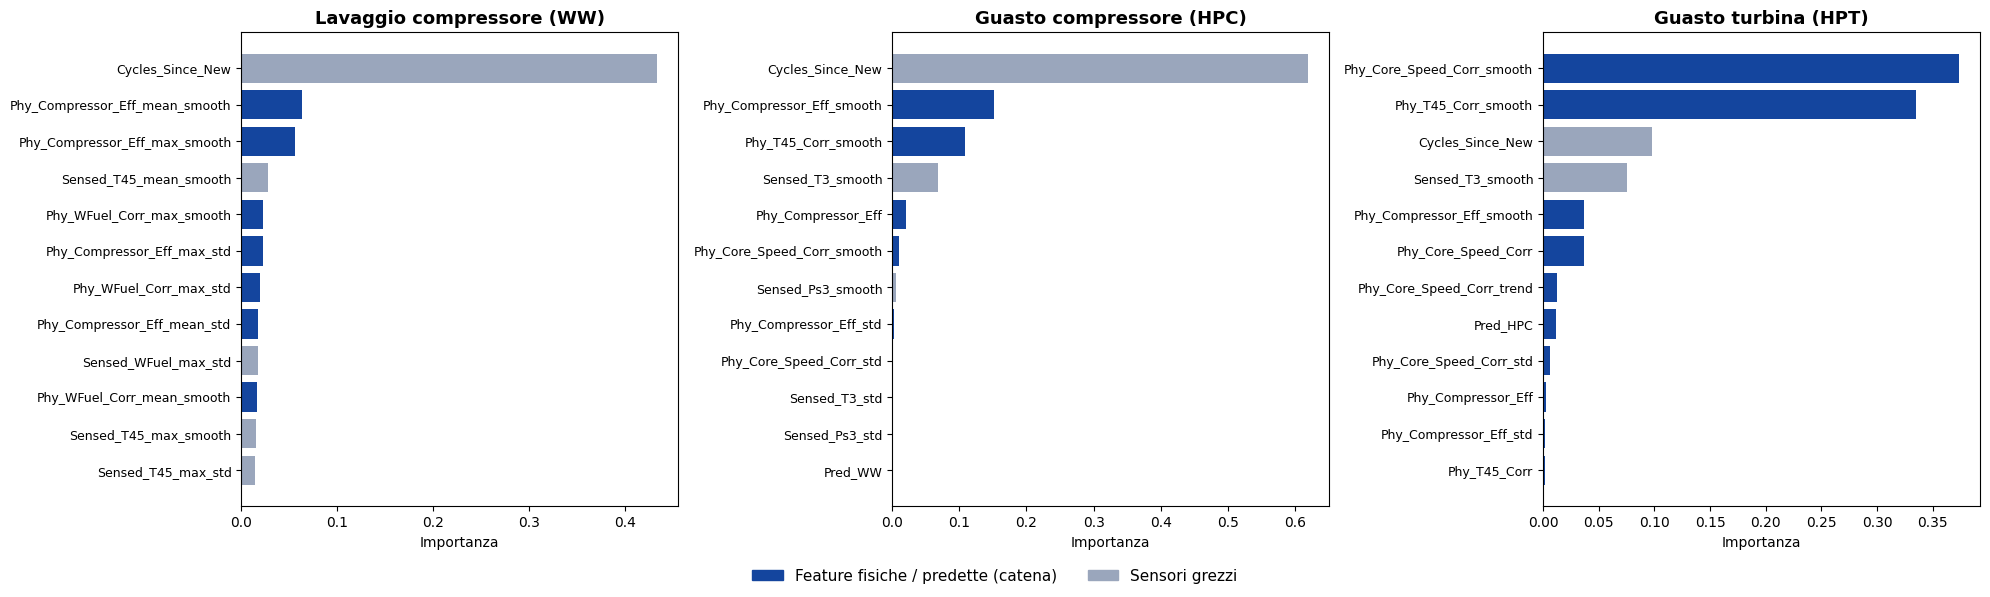


Salvato: feature_importance_modello_finale.png


In [3]:
# === IMPORTANZA DELLE FEATURE DEL MODELLO FINALE (catena Domino) ===
# Incollare in una cella NUOVA, dopo aver eseguito la cella che definisce
# harmonize_columns / prepare_* / optimize_margins_oof.
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.impute import SimpleImputer

# 1) Ricarico il training come in main()
if os.path.exists('data_elaborated/train/train_cleaned.csv'):
    df_raw = pd.read_csv('data_elaborated/train/train_cleaned.csv')
else:
    df_raw = pd.read_csv('data_elaborated/train/train_with_physics_residuals.csv')
df_raw = harmonize_columns(df_raw)

df_mech = prepare_mechanical_data(df_raw, is_test=False)
df_wash = prepare_wash_data(df_raw, is_test=False)

tasks = [
    {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW'},
    {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC'},
    {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT'},
]

importances = {}
oof_predictions_dict = {}

for task in tasks:
    target, df, ctype = task['target'], task['data'].copy(), task['type']
    if target not in df.columns or 'ESN' not in df.columns:
        continue

    # Catena Domino, identica a main()
    if ctype == 'HPC':
        df = df.set_index(['ESN', 'Cycles_Since_New'])
        df['Pred_WW'] = oof_predictions_dict['WW']
        df = df.reset_index()
        df['Pred_WW'] = df['Pred_WW'].fillna(df['Cycles_to_WW'])
    elif ctype == 'HPT':
        df = df.set_index(['ESN', 'Cycles_Since_New'])
        df['Pred_WW'] = oof_predictions_dict['WW']
        df['Pred_HPC'] = oof_predictions_dict['HPC']
        df = df.reset_index()
        df['Pred_WW'] = df['Pred_WW'].fillna(df['Cycles_to_WW'])
        df['Pred_HPC'] = df['Pred_HPC'].fillna(df['Cycles_to_HPC_SV'])

    features = [c for c in df.columns if c not in ['ESN', target, 'Snapshot'] and 'Cycles_to_' not in c]
    X, y, groups = df[features], df[target], df['ESN']
    max_train_val = y.max()

    imputer = SimpleImputer(strategy='mean')
    X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)

    if ctype == 'WW':
        params = {'loss':'huber','n_estimators':300,'max_depth':6,'learning_rate':0.05,'subsample':1.0,'random_state':42}
    else:
        params = {'loss':'huber','n_estimators':500,'max_depth':4,'learning_rate':0.03,'subsample':0.7,'random_state':42}

    final_model, best_a, best_b, oof_preds = optimize_margins_oof(X_clean, y, groups, params, ctype, max_train_val)
    importances[ctype] = (features, final_model.feature_importances_)

    oof_series = pd.Series(oof_preds, index=pd.MultiIndex.from_arrays([df['ESN'], df['Cycles_Since_New']]))
    oof_predictions_dict[ctype] = oof_series

# 2) Grafico: un pannello per evento, top-12 feature; fisiche/predette in blu, sensori grezzi in grigio
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = {'WW':'Lavaggio compressore (WW)', 'HPC':'Guasto compressore (HPC)', 'HPT':'Guasto turbina (HPT)'}
TOPN = 12
for ax, ctype in zip(axes, ['WW','HPC','HPT']):
    feats, imp = importances[ctype]
    order = np.argsort(imp)[::-1][:TOPN]
    names = [feats[i] for i in order]
    vals  = [imp[i] for i in order]
    colors = ['#14459E' if (n.startswith('Phy_') or n.startswith('Pred_')) else '#9AA6BC' for n in names]
    ax.barh(range(len(names)), vals, color=colors)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(titles[ctype], fontsize=13, fontweight='bold'); ax.set_xlabel('Importanza')
    # stampo anche il top-5 in testo, utile da citare
    print(f"\n[{ctype}] Top 5 feature:")
    for i in order[:5]:
        print(f"   {feats[i]:35s} {imp[i]:.4f}")

fig.legend(handles=[Patch(color='#14459E', label='Feature fisiche / predette (catena)'),
                    Patch(color='#9AA6BC', label='Sensori grezzi')],
           loc='lower center', ncol=2, fontsize=11, frameon=False)
plt.tight_layout(rect=[0,0.05,1,1])
plt.savefig('feature_importance_modello_finale.png', dpi=200, bbox_inches='tight')
plt.show()
print("\nSalvato: feature_importance_modello_finale.png")